# Experimentation and Implementation

I plan on using this python notebook as a way to formulate how my neural networks should work. If you are reading this without having read the README.md I will quickly explain the goals of this project:

This project is meant to serve both as an introduction to protein folding via machine learning, and to test the potential strength of a relatively new algorithm named 'ProtTrans' which can take a string of protein residues and transform the input into a string that would be easier to read and train a neural network on for feasable proteins.

As a quick mark, here are the things I need to do in this file:
1) Import protein residue data
2) Processes, refine, and reduce data so that the nn can be trained quickly to experiment and adapt
3) build and train neural network that takes in residues straight.
4) incorporate ProtTrans, feed data in, and store output
5) build and train another neural network on ProtTrans output data
6) Optimize hyperparameters for both neural networks and experiment with various values like depth and # of hidden nodes.
7) print graphs and data to compare and analyize

I am not entirely sure what type of output the cnn should provide, it can either provide a 0-1 value of certainty of contact, then we use a cutoff to decide what is a contact or not, or it can provide a distance metric that we then filter to however many A we want to use to denote a "contact"


# Imports and dependencies

In [2]:
import torch
from torch import nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import islice


# Importing Protein Data

I will use the following code box to try and visualize the data given in the 'adataset' pdb file. 

The key features I need to be able to extract are name, length, amino acid residues, and the contact map.

A lot of this is written in a way that should make it easy to apply this to the whole database.

['5D8VA', '1EJGA', '2VB1A', '1R6JA', '1US0A', '1P9GA', '1YK4A', '6S2MA', '3X2MA', '2H5CA', '4I8HA', '7BNHB', '1GCIA', '3UI4A', '2VXNA', '2WFIA', '2O7AA', '3X34A', '1M40A', '4REKA', '2JFRA', '6JGIA', '1UCSA', '7KR0A', '1GWEA', '4AYOA', '6Q00A', '6Q00B', '3Q8JA', '5AL6A', '1I1WA', '2O9SA', '3O4PA', '5YOKB', '6ETLA', '2YKZA', '4U9HL', '4U9HS', '4EICA', '1MC2A', '1X8QA', '7A5MA', '2OV0A', '4Y9VA', '6ZM8A', '5GV8A', '7BBXA', '6TJ8A', '1G6XA', '5TDAA', '3ZOJA', '2B97A', '3QPAA', '1KWFA', '5NFMA', '1IQZA', '5HB7A', '4PSYA', '4Y9WA', '5AKRA', '6EIOA', '6KFNA', '4F1UA', '3EA6A', '6EQEA', '3WDNA', '2BT9C', '6HSAA', '5O99A', '7R25A', '4A02A', '1IX9A', '1NWZA', '1G66A', '7OTUA', '5LP9A', '2FDNA', '1J0PA', '6KLZA', '1W0NA', '1OK0A', '4KXVA', '1BXOA', '6SYJA', '6FMCA', '4AWTA', '3V1AA', '3QR7B', '2Y78A', '2GKGA', '6RI6A', '2PVBA', '5MK9A', '1V6PB', '4NPDA', '5I5BA', '6YTUA', '2FVYA', '4MZCA', '5EMBA', '6TWTB', '5A71A', '3WOUA', '2XOMA', '2RH2A', '2XJPA', '1S5NA', '2V8TA', '7PSYC', '4UNUA', '5A8CA', 

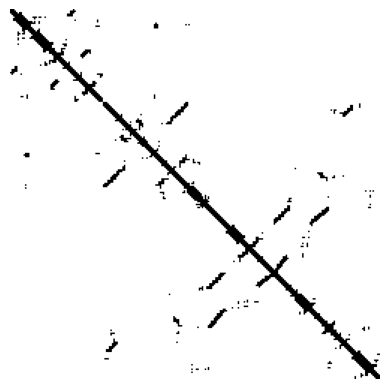

In [ ]:
with open("pdb.fasta_qual.16Nov2022.adataset") as pdb_adataset:
    # Extract the data we need from the slice of the dataset
    segment = list(islice(pdb_adataset, 16))
    data = {"name": [], "length": [], "proteins": [], "xyz": []}
    data["name"].append(segment[0].replace("\n", ""))
    data["length"].append(int(segment[1]))

    # protein and coords need extra care, as they are lists in the dict list
    data["proteins"].append(
        segment[2].replace("\n", "")
            .split("\t")
    )
    del data["proteins"][0][-1]

    data["xyz"].append(
        segment[13].replace("\n", "")
            .split("\t")
        )
    del data["xyz"][0][-1]

    # We are going to use a for loop to turn the xyz coordinates into floats and make the triplet lists
    i = 0
    for string in data["xyz"][0]:
        data["xyz"][0][i] = list(map(float, string.split(" ")))
        i += 1

print(data["name"][0])
print(data["length"][0])
print(data["proteins"][0])
print(len(data["proteins"][0]))
print(data["xyz"][0])
print(len(data["xyz"][0]))

# Calculating and printing the contact map
contact = []
for coord1 in data["xyz"][0]:
    temp = []
    for coord2 in data["xyz"][0]:
        distance = np.linalg.norm(np.array(coord1) - np.array(coord2))
        if (distance <= 8): val = 0
        else: val = 1
        temp.append(val)
    contact.append(temp)
fig, ax = plt.subplots()
ax.imshow(np.matrix(contact), cmap='gray')
ax.axis('off')
plt.show()

In [ ]:
with open("pdb.fasta_qual.16Nov2022_30.fasta") as pdb_fasta:
    fasta_lines = pdb_fasta.readlines()[0::2]
fasta_lines = [s.replace('>', '') for s in fasta_lines]
fasta_lines = [s.replace('\n', '') for s in fasta_lines]
print(fasta_lines)

data = {"name": [], "length": [], "proteins": [], "xyz": []}
with open("pdb.fasta_qual.16Nov2022.adataset") as pdb_adataset:
    while True:
        segment = list(islice(pdb_adataset, 16))
        if not segment: # If there are no more lines we break the loop.
            break

        name = segment[0].replace("\n", "")
        print(name, end=" ")
        if fasta_lines in fasta_lines:
            data["name"].append()
            data["length"].append(int(segment[1]))

            proteins = segment[2].replace("\n", "").split("\t")
            del proteins[-1]
            data["proteins"].append(proteins)

            coords = segment[13].replace("\n", "").split("\t")
            del coords[-1]

            i = 0
            for string in coords:
                coords[i] = list(map(float, string.split(" ")))
                i += 1
            data["xyz"].append(coords)
            
df = pd.DataFrame(data)


['5D8VA', '1EJGA', '2VB1A', '1R6JA', '1US0A', '1P9GA', '1YK4A', '6S2MA', '3X2MA', '2H5CA', '4I8HA', '7BNHB', '1GCIA', '3UI4A', '2VXNA', '2WFIA', '2O7AA', '3X34A', '1M40A', '4REKA', '2JFRA', '6JGIA', '1UCSA', '7KR0A', '1GWEA', '4AYOA', '6Q00A', '6Q00B', '3Q8JA', '5AL6A', '1I1WA', '2O9SA', '3O4PA', '5YOKB', '6ETLA', '2YKZA', '4U9HL', '4U9HS', '4EICA', '1MC2A', '1X8QA', '7A5MA', '2OV0A', '4Y9VA', '6ZM8A', '5GV8A', '7BBXA', '6TJ8A', '1G6XA', '5TDAA', '3ZOJA', '2B97A', '3QPAA', '1KWFA', '5NFMA', '1IQZA', '5HB7A', '4PSYA', '4Y9WA', '5AKRA', '6EIOA', '6KFNA', '4F1UA', '3EA6A', '6EQEA', '3WDNA', '2BT9C', '6HSAA', '5O99A', '7R25A', '4A02A', '1IX9A', '1NWZA', '1G66A', '7OTUA', '5LP9A', '2FDNA', '1J0PA', '6KLZA', '1W0NA', '1OK0A', '4KXVA', '1BXOA', '6SYJA', '6FMCA', '4AWTA', '3V1AA', '3QR7B', '2Y78A', '2GKGA', '6RI6A', '2PVBA', '5MK9A', '1V6PB', '4NPDA', '5I5BA', '6YTUA', '2FVYA', '4MZCA', '5EMBA', '6TWTB', '5A71A', '3WOUA', '2XOMA', '2RH2A', '2XJPA', '1S5NA', '2V8TA', '7PSYC', '4UNUA', '5A8CA', 

# Creating a Convolutional Neural Network